In [40]:
bostonDF = pd.read_csv('/Users/rex/Desktop/hong/cuai/BostonHousing.csv')
bostonDF.rename(columns={'crim':'CRIM', 'zn':'ZN', 'indus':'INDUS', 'chas':'CHAS', 'nox':'NOX', 
                         'rm':'RM', 'age':'AGE', 'dis':'DIS', 'rad':'RAD', 'tax':'TAX', 'ptratio':'PTRATIO', 
                         'b':'B', 'lstat':'LSTAT', 'medv':'MEDV'}, inplace=True)
bostonDF.rename(columns={'MEDV':'PRICE'}, inplace=True)

# drop the column 'B' and 'LSTAT' due to ethical issues
bostonDF = bostonDF.drop(columns=['B', 'LSTAT'])

# In this dataset, 5 rooms turned out to be null values. Fill them with the mean of the column.
bostonDF.fillna(bostonDF.mean(), inplace=True)

bostonDF.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,36.2


In [48]:
#규제 선형 모델 - 릿지, 라쏘, 엘라스틱넷
#비용함수 목표 = MIN(RSS(W)+alpha|w|)
#L2규제- 릿지 회귀, L1규제- 라쏘 회귀
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

y_target = bostonDF['PRICE']
X_data = bostonDF.drop(['PRICE'], axis=1, inplace=False)

ridge=Ridge(alpha=10)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_square_error', cv = 5)
rmse_scores = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)
print('5 folds 의 개별 Negative MSE scores:', np.round(neg_mse_scores))
print('5 folds 의 개별 RMSE scores:', np.round(rmse_scores, 3))
pritn('5 folds 의 평균 RMSE: {0:.3f}'.format(avg_rmse))

InvalidParameterError: The 'scoring' parameter of cross_val_score must be a str among {'precision', 'balanced_accuracy', 'neg_negative_likelihood_ratio', 'precision_macro', 'neg_root_mean_squared_error', 'neg_mean_squared_log_error', 'roc_auc_ovr_weighted', 'recall_samples', 'neg_mean_squared_error', 'neg_mean_absolute_error', 'normalized_mutual_info_score', 'f1_micro', 'roc_auc_ovr', 'matthews_corrcoef', 'completeness_score', 'v_measure_score', 'recall_macro', 'accuracy', 'recall_micro', 'neg_mean_poisson_deviance', 'homogeneity_score', 'roc_auc', 'neg_brier_score', 'adjusted_rand_score', 'f1_weighted', 'max_error', 'recall', 'd2_absolute_error_score', 'top_k_accuracy', 'f1_macro', 'explained_variance', 'jaccard_macro', 'jaccard_samples', 'jaccard_weighted', 'mutual_info_score', 'precision_samples', 'roc_auc_ovo_weighted', 'r2', 'f1', 'jaccard_micro', 'jaccard', 'precision_weighted', 'f1_samples', 'average_precision', 'positive_likelihood_ratio', 'precision_micro', 'roc_auc_ovo', 'neg

In [50]:
#릿지에 사용될 alpha 파라미터의 값 정의
alphas = [0,0.1,1,10,100]

#alpha list 값을 반복하면서 alpha에 따른 평균 rmse를 구함.
for alpha in alphas: 
    ridge = Ridge(alpha=alpha)

    #cross val score를 이용해 5 폴드의 평균 RMSE를 계산
    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring="neg_mean_squared_error", cv=5)
    avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
    print('alpha {0} 일 때 5folds의 평균 RMSE : {1:.3f}'.format(alpha, avg_rmse))
#알파 10일떄 굳

alpha 0 일 때 5folds의 평균 RMSE : 6.384
alpha 0.1 일 때 5folds의 평균 RMSE : 6.335
alpha 1 일 때 5folds의 평균 RMSE : 6.152
alpha 10 일 때 5folds의 평균 RMSE : 5.962
alpha 100 일 때 5folds의 평균 RMSE : 6.100


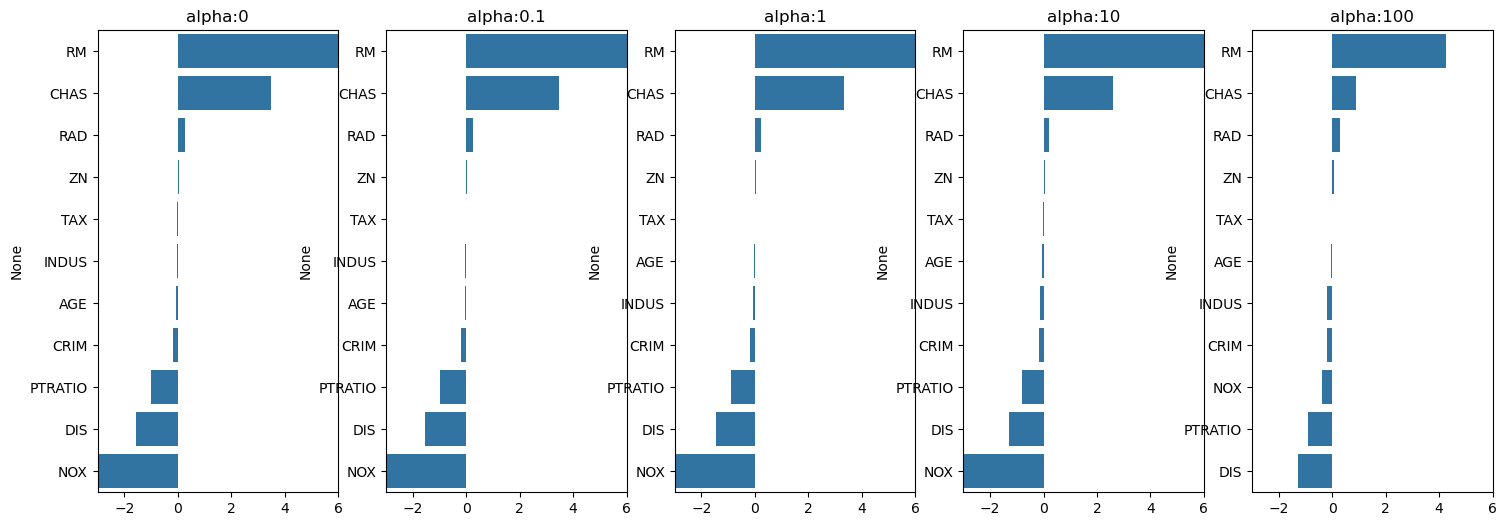

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize=(18,6), nrows = 1, ncols = 5)
#각 alpha에 따른 회귀 계수 값을 데이터롤 저장하기 위한 DataFrame 생성
coeff_df = pd.DataFrame()

#alphas 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장. pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_data, y_target)
    #alpha에 따른 피처별로 회귀 계수 series로 변환하고 이를 DataFrame의 칼럼으로 추가
    coeff = pd.Series(data=ridge.coef_, index=X_data.columns)
    colname='alpha:'+str(alpha)
    coeff_df[colname] = coeff
    #막대 그래프로 각 alpha 값에서의 회귀 계수를 시각화. 회귀 계수 값이 높은 순으로 표현
    coeff=coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])

In [58]:
ridge_alphas = [0,0.1,1,10,100]
sort_column = 'alpha:'+str(ridge_alphas[0])
coeff_df.sort_values(by=sort_column, ascending=False)

,alpha:0,alpha:0.1,alpha:1,alpha:10,alpha:100
RM,6.070800,6.087056,6.165530,6.051154,4.257640
CHAS,3.487923,3.469868,3.337585,2.596757,0.899998
RAD,0.257052,0.253694,0.235878,0.221658,0.279919
ZN,0.039076,0.039248,0.040254,0.043013,0.052102
TAX,-0.012344,-0.012454,-0.013083,-0.014540,-0.017661
INDUS,-0.039803,-0.045706,-0.078186,-0.127905,-0.177251
AGE,-0.044926,-0.046250,-0.053484,-0.063282,-0.061299
CRIM,-0.184109,-0.183742,-0.181944,-0.183390,-0.205519
PTRATIO,-0.996621,-0.981828,-0.901923,-0.810461,-0.906524
DIS,-1.565724,-1.546336,-1.440546,-1.298511,-1.267201


In [68]:
#라쏘 회귀
#적절한 피처만 회귀에 포함
from sklearn.linear_model import Lasso, ElasticNet

#alpha 값에 따른 회귀 모델의 폴드 평균 RMSE를 출력하고 회귀 계수 값들을 DataFrame으로 반환
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None, verbose=True, return_coeff=True):
    coeff_df = pd.DataFrame()
    if verbose : print('######', model_name, '######')
    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha=param)
        elif model_name == 'Lasso': model = Lasso(alpha=param)
        elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring = "neg_mean_squared_error", cv=5)
        avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
        print('alpha {0}일 때 5 폴드 세트의 평균 RMSE: {1:.3f}'.format(param, avg_rmse))
        #cross_val_score는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀 계수 추출

        model.fit(X_data_n, y_target_n)
        if return_coeff:
            #alpha에 따른 피처별 회귀 계수를 series로 변환하고 이를 dataframe의 칼럼으로 추가.
            coeff = pd.Series(data=model.coef_ , index=X_data_n.columns)
            colname='alpha:'+str(param)
            coeff_df[colname] = coeff

    return coeff_df
#end of get_linear_regre_eval
#라쏘에 사용될 parameter의 값을 정의하고 get_linear_reg_eval() 함수 호출
lasso_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)
#알파 0.1일떄  

###### Lasso ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 6.095
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 6.022
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 6.153
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.498
alpha 3일 때 5 폴드 세트의 평균 RMSE: 7.734


In [64]:
#반환된 coeff_lasso_df를 첫번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,6.274226,6.225032,5.440985,4.396376,0.063037
CHAS,2.269514,1.799852,0.000000,0.000000,0.000000
RAD,0.205420,0.208510,0.213650,0.201852,0.143192
ZN,0.041743,0.041783,0.041533,0.040826,0.055060
NOX,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000
TAX,-0.014655,-0.014930,-0.016257,-0.016727,-0.018588
AGE,-0.065105,-0.064229,-0.055183,-0.045207,-0.019594
INDUS,-0.127565,-0.123161,-0.097345,-0.081680,-0.072133
CRIM,-0.178459,-0.179091,-0.175739,-0.165607,-0.134469
PTRATIO,-0.758160,-0.763988,-0.771556,-0.745639,-0.567892


In [70]:
#엘라스틱넷 회귀
#L2+L1 결합 
#엘라스틱 넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
#l1_ratio는 0.7로 고정
elastic_alphas = [0.07, 0.1, 0.5, 1, 3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas, X_data_n=X_data, y_target_n=y_target)

###### ElasticNet ######
alpha 0.07일 때 5 폴드 세트의 평균 RMSE: 5.983
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 5.976
alpha 0.5일 때 5 폴드 세트의 평균 RMSE: 6.193
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.521
alpha 3일 때 5 폴드 세트의 평균 RMSE: 7.537


In [74]:
#반환된 coeff_elastic_df를 첫 번째 칼럼순으로 내림차순 정렬해 회귀계수 DataFrame 출력
sort_colums = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
RM,5.981834,5.830584,4.130503,2.826883,0.650357
CHAS,1.981244,1.579109,0.000000,0.000000,0.000000
RAD,0.219888,0.224128,0.261592,0.265908,0.192746
ZN,0.043406,0.044196,0.049717,0.052168,0.053030
TAX,-0.015086,-0.015517,-0.017858,-0.018802,-0.019223
AGE,-0.064176,-0.064184,-0.055707,-0.047098,-0.022267
INDUS,-0.132283,-0.136088,-0.147773,-0.150735,-0.095126
CRIM,-0.183448,-0.185183,-0.195259,-0.192985,-0.155198
PTRATIO,-0.793053,-0.796637,-0.865088,-0.855259,-0.615240
NOX,-0.807856,-0.000000,-0.000000,-0.000000,-0.000000


In [96]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
import numpy as np
#선형 회귀 모델을 위한 데이터 변환
#일반적으로 타킷값은 로그변환을 한다. 
#method는 표준 정규 분포 변환(standard), 최댓값/최솟값 정규화(minmax), 로그변환(log) 결정
#p_degree는 다항식 특성을 추가할 때 적용. p_degree는 2이상 부여하지 않음
def get_scaled_data(method='None', p_degree=None, input_data=None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data

    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data)
    return scaled_data

In [98]:
alphas = [0.1, 1, 10, 100]

#5개 방식으로 변환 먼저 원본 그대로, 표준정규분포, 포준정규분포+다항식 특성
#최대/최소 정규화, 최대/최소 정규화+다항식 특성, 로그변환

scale_methods = [(None, None), ('Standard', None), ('Standard', 2), ('MinMax', None), ('MinMax', 2), ('Log', None)]
for scale_method in scale_methods:
    X_data_scaled = get_scaled_data(method=scale_method[0], p_degree=scale_method[1], input_data = X_data)
    print('\n## 변환 유형:{0}, Polynomial Degree:{1}'.format(scale_method[0], scale_method[1]))
    get_linear_reg_eval('Ridge', params=alphas, X_data_n=X_data_scaled, y_target_n=y_target, verbose=False, return_coeff=False)


## 변환 유형:None, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 6.335
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.152
alpha 10일 때 5 폴드 세트의 평균 RMSE: 5.962
alpha 100일 때 5 폴드 세트의 평균 RMSE: 6.100

## 변환 유형:Standard, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 6.381
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.360
alpha 10일 때 5 폴드 세트의 평균 RMSE: 6.204
alpha 100일 때 5 폴드 세트의 평균 RMSE: 6.028

## 변환 유형:Standard, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 10.417
alpha 1일 때 5 폴드 세트의 평균 RMSE: 8.630
alpha 10일 때 5 폴드 세트의 평균 RMSE: 6.425
alpha 100일 때 5 폴드 세트의 평균 RMSE: 5.286

## 변환 유형:MinMax, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 6.330
alpha 1일 때 5 폴드 세트의 평균 RMSE: 6.125
alpha 10일 때 5 폴드 세트의 평균 RMSE: 6.561
alpha 100일 때 5 폴드 세트의 평균 RMSE: 7.984

## 변환 유형:MinMax, Polynomial Degree:2
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 6.072
alpha 1일 때 5 폴드 세트의 평균 RMSE: 5.186
alpha 10일 때 5 폴드 세트의 평균 RMSE: 6.019
alpha 100일 때 5 폴드 세트의 평균 RMSE: 7.249

## 변환 유형:Log, Polynomial Degree:None
alpha 0.1일 때 5 폴드 세트의 평균 RMSE: 6.06

In [102]:
#로지스틱 회귀
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [106]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#평균 0 분산 1데이터 분포도
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train,  X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3, random_state=0)

In [110]:
#학습 및 예측
from sklearn.metrics import accuracy_score, roc_auc_score

lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)

print('accuracy:{0:.3f}, roc_auc:{1:.3f}'.format(accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds)))

accuracy:0.977, roc_auc:0.972


In [112]:
#서로 다른 solver 값으로
solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']

for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    lr_preds = lr_clf.predict(X_test)

    #accuracy와 roc_auc 측정
    print('solver:{0}, accuracy: {1:.3f}, roc_auc:{2:3f}'.format(solver, accuracy_score(y_test, lr_preds), roc_auc_score(y_test, lr_preds)))

solver:lbfgs, accuracy: 0.977, roc_auc:0.971561
solver:liblinear, accuracy: 0.982, roc_auc:0.979497
solver:newton-cg, accuracy: 0.977, roc_auc:0.971561
solver:sag, accuracy: 0.982, roc_auc:0.979497
solver:saga, accuracy: 0.982, roc_auc:0.979497


In [114]:
# liblinear, saga 는 l1,l2 규제 모두 가능 lbfgs,newton-cg,sag 는 l2 규제만
from sklearn.model_selection import GridSearchCV
params={'solver':['liblinear', 'lbfgs'], 'penalty':['l2', 'l1'], 'C':[0.01, 0.1, 1, 1, 5, 10]}

lr_clf = LogisticRegression()

grid_clf = GridSearchCV(lr_clf, param_grid = params, scoring='accuracy', cv=3)
grid_clf.fit(data_scaled, cancer.target)
print('최적 하이퍼 파라미터:{0}, 최적 평균 정확도:{1:.3f}'.format(grid_clf.best_params_, grid_clf.best_score_))


최적 하이퍼 파라미터:{'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}, 최적 평균 정확도:0.979


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
18 fits failed out of a total of 72.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py", line 1194, in fit
    solver